# Imports

Nesta seção são importadas as bibliotecas necessárias para:
- carregar e manipular dados (`pandas`, `numpy`);
- plotar gráficos (`matplotlib`);
- criar e avaliar modelos de regressão (`sklearn`).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics as mt

# Dataset

Neste bloco são carregados os conjuntos de dados de treino, validação e teste.
Os dados são lidos de arquivos CSV separados para manter o processo de avaliação correto.

In [2]:
# Carregando dados de treinamento/classificação
X_train =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_treinamento/X_training.csv')
y_train =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_treinamento/y_training.csv')

In [4]:
# Carregando dados de validação/classificação
X_val =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_validacao/X_validation.csv')
y_val =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_validacao/y_validation.csv')

In [5]:
# Carregando dados de teste/Classificação
X_test =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_teste/X_test.csv')
y_test =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_teste/y_test.csv')


# Traning

## knn

Nesta etapa foi feito o ajuste do modelo KNN:
- treinou-se o classificador para valores de `n_neighbors` de 1 a 49;
- avaliou-se a acurácia no conjunto de validação para cada valor;
- armazenaram-se as pontuações de validação;
- foram armazenadas as pontuações de performace com dados de treinamento, validação e teste
- foi preparada a visualização da acurácia em função de `k`.

In [6]:
## Modelo treinado e validado com o dataset de Treinamento
values_knn = [i for i in range(1,50)]
val_scores_knn = list()

for i in values_knn:
    model_knn = KNeighborsClassifier(n_neighbors=i)
    model_knn.fit(X_train, y_train)

    yhat_val_knn = model_knn.predict(X_val)
    acc_val_knn = mt.accuracy_score(y_val, yhat_val_knn)
    val_scores_knn.append(acc_val_knn)

/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/ne

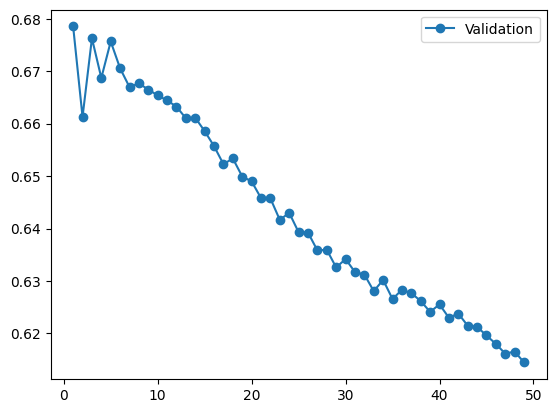

In [7]:
## plot of train and test scores vs tree depth
plt.plot( values_knn, val_scores_knn, '-o', label='Validation' )
plt.legend()
plt.show()

In [8]:
## Previsão sobre os dados de validacao
yhat_val_knn = model_knn.predict( X_val )
acc_val_knn = mt.accuracy_score( y_val, yhat_val_knn )
print( "Accuracy Over Validation: {}".format( acc_val_knn ) )

Accuracy Over Validation: 0.6144663599214903


In [9]:
## Modelo treinado e validado com o dataset de Treinamento + validacao
max_index_knn = val_scores_knn.index( max( val_scores_knn ) )
model_last_knn = KNeighborsClassifier(n_neighbors=values_knn[max_index_knn])
model_last_knn.fit( np.concatenate( (X_train, X_val) ), np.concatenate((y_train, y_val)) )

/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [10]:
max_index_knn

0

In [13]:
## Previsão sobre os dados de treinamento
yhat_train_knn = model_last_knn.predict( X_train )
acc_train_knn = mt.accuracy_score( y_train, yhat_train_knn )
precision_train_knn = mt.precision_score(y_train, yhat_train_knn)
recall_train_knn = mt.recall_score(y_train, yhat_train_knn)
f1_score_train_knn = mt.f1_score(y_train, yhat_train_knn)

print(f"F1 Score: {f1_score_train_knn}")
print(f"Precision: {precision_train_knn}")
print(f"Recall: {recall_train_knn}")
print( "Accuracy Over Training: {}".format( acc_train_knn ) )

/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


F1 Score: 1.0
Precision: 1.0
Recall: 1.0
Accuracy Over Training: 1.0


In [14]:
## Previsão sobre os dados de validação
yhat_val_knn = model_last_knn.predict( X_val )
acc_val_knn = mt.accuracy_score( y_val, yhat_val_knn )
precision_val_knn = mt.precision_score(y_val, yhat_val_knn)
recall_val_knn = mt.recall_score(y_val, yhat_val_knn)
f1_score_val_knn = mt.f1_score(y_val, yhat_val_knn)

print(f"F1 Score: {f1_score_val_knn}")
print(f"Precision: {precision_val_knn}")
print(f"Recall: {recall_val_knn}")
print( "Accuracy Over Validation: {}".format( acc_val_knn ) )

/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


F1 Score: 1.0
Precision: 1.0
Recall: 1.0
Accuracy Over Validation: 1.0


In [15]:
## Previsão sobre os dados de test
yhat_test_knn = model_last_knn.predict( X_test )
acc_test_knn = mt.accuracy_score( y_test, yhat_test_knn )
precision_knn = mt.precision_score(y_test, yhat_test_knn)
recall_knn = mt.recall_score(y_test, yhat_test_knn)
f1_score_knn = mt.f1_score(y_test, yhat_test_knn)

print(f"F1 Score: {f1_score_knn}")
print(f"Precision: {precision_knn}")
print(f"Recall: {recall_knn}")
print( "Accuracy Over Test: {}".format( acc_test_knn ) )

/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


F1 Score: 0.6597794342007759
Precision: 0.6537664132688321
Recall: 0.665904091509019
Accuracy Over Test: 0.6985671803190051


## Decision Tree

## Decision Tree

Nesta seção foi realizado o ajuste e a avaliação de um classificador `DecisionTreeClassifier`:

- Definiu-se uma faixa de profundidades máximas (`max_depth`) de 1 a 49.
- Para cada valor de `max_depth`:
    - criou-se um modelo `DecisionTreeClassifier(max_depth=i)`;
    - treinou-se com `X_train` e `y_train`;
    - fez-se previsão sobre `X_val` (dados de validação);

- Traçou-se a curva de acurácia de validação em função de `max_depth`.

- Calculou-se a performance do último modelo treinado (`model_dt`, com `max_depth=49`) sobre:
    - dados de treinamento;
    - dados de validação.

- Selecionou-se o melhor `max_depth` usando o valor máximo de acurácia em `val_scores_dt`.

- Re-treinou-se o modelo final (`model_last_dt`) com o conjunto combinado de treinamento e validação (`X_train + X_val`, `y_train + y_val`) usando o melhor `max_depth`.

- Avaliou-se o modelo final sobre o conjunto de teste (`X_test`, `y_test`) e registrou-se:
    - acurácia;
    - precisão;
    - recall;
    - F1 score.

In [14]:
## Modelo treinado e validado com o dataset de Treinamento
values_dt = [i for i in range(1,50)]
val_scores_dt = list()

for i in values_dt:
    model_dt = DecisionTreeClassifier(max_depth=i)
    model_dt.fit(X_train, y_train)

    yhat_val_dt = model_dt.predict(X_val)
    acc_val_dt = mt.accuracy_score(y_val, yhat_val_dt)
    val_scores_dt.append(acc_val_dt)

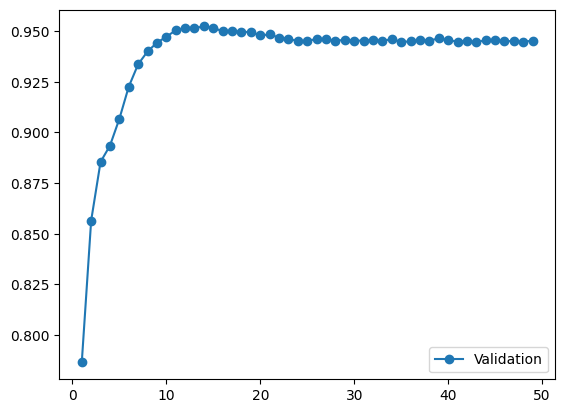

In [15]:
## plot of train and test scores vs tree depth
plt.plot( values_dt, val_scores_dt, '-o', label='Validation' )
plt.legend()
plt.show()

In [56]:
## Previsão sobre os dados de treinamento
yhat_train_dt = model_dt.predict( X_train )
acc_train_dt = mt.accuracy_score( y_train, yhat_train_dt )
precision_train_dt = mt.precision_score(y_train, yhat_train_dt)
recall_train_dt = mt.recall_score(y_train, yhat_train_dt)
f1_score_train_dt = mt.f1_score(y_train, yhat_train_dt)

print(f"F1 Score: {f1_score_train_dt}")
print(f"Precision: {precision_train_dt}")
print(f"Recall: {recall_train_dt}")
print( "Accuracy Over Training: {}".format( acc_train_dt ) )

F1 Score: 1.0
Precision: 1.0
Recall: 1.0
Accuracy Over Training: 1.0


In [53]:
## Previsão sobre os dados de validação
yhat_val_dt = model_dt.predict( X_val )
acc_val_dt = mt.accuracy_score( y_val, yhat_val_dt )
precision_val_dt = mt.precision_score(y_val, yhat_val_dt)
recall_val_dt = mt.recall_score(y_val, yhat_val_dt)
f1_score_val_dt = mt.f1_score(y_val, yhat_val_dt)

print(f"F1 Score: {f1_score_val_dt}")
print(f"Precision: {precision_val_dt}")
print(f"Recall: {recall_val_dt}")
print( "Accuracy Over Validation: {}".format( acc_val_dt ) )

F1 Score: 0.9370432201817844
Precision: 0.9364526175292897
Recall: 0.9376345682678744
Accuracy Over Validation: 0.9453972135525596


In [54]:
## Modelo treinado e validado com o dataset de Treinamento
max_index_dt = val_scores_dt.index( max( val_scores_dt ) ) # Encontrar o índice do valor máximo de acurácia na lista de acurácias de validação
model_last_dt = DecisionTreeClassifier(max_depth=values_dt[max_index_dt])
model_last_dt.fit( np.concatenate( (X_train, X_val) ), np.concatenate((y_train, y_val)) )

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",14
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [20]:
## Previsão sobre os dados de test
yhat_test_dt = model_last_dt.predict( X_test )
acc_test_dt = mt.accuracy_score( y_test, yhat_test_dt )
precision_dt = mt.precision_score(y_test, yhat_test_dt)
recall_dt = mt.recall_score(y_test, yhat_test_dt)
f1_score_dt = mt.f1_score(y_test, yhat_test_dt)

print(f"F1 Score: {f1_score_dt}")
print(f"Precision: {precision_dt}")
print(f"Recall: {recall_dt}")
print( "Accuracy Over Test: {}".format( acc_test_dt ) )

F1 Score: 0.95012402551382
Precision: 0.9566497190259566
Recall: 0.9436867575890893
Accuracy Over Test: 0.9565133433746572


/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


## Random Forest

Nesta seção foi ajustado e avaliado um classificador `RandomForestClassifier`.

- Foi testado um conjunto de valores para `n_estimators` e `max_depth` usando o conjunto de validação.
- Para cada combinação de parâmetros:
    - o modelo foi treinado em `X_train` e `y_train`;
    - foi feita a previsão em `X_val`;
    - calculou-se a acurácia de validação.
- A melhor combinação de parâmetros foi identificada com base na maior acurácia em validação.
- Em seguida, o modelo final foi re-treinado usando o conjunto combinado de treinamento e validação (`X_train + X_val`, `y_train + y_val`).
- Por fim, o modelo final foi avaliado com dados de treinamento, validação e teste, registrando acurácia, precisão, recall e F1 score.

In [ ]:
## Modelo treinado e validado com o dataset de Treinamento
values_rf = [i for i in range(1,50)]
val_scores_rf = list()

for i in values_rf:
    model_rf = RandomForestClassifier(n_estimators=i)
    model_rf.fit(X_train, y_train)

    yhat_val_rf = model_rf.predict(X_val)
    acc_val_rf = mt.accuracy_score(y_val, yhat_val_rf)
    val_scores_rf.append(acc_val_rf)

/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/s

In [ ]:
#testando conjunto de valores combinados usando os dados de treinamento e validação
values_rf = [40,41,42,46]
values_max_depth = [29,30,31,33]

val_scores_rf = []
best_rf = {'n_estimators': None, 'max_depth': None, 'accuracy': 0.0}

for n in values_rf:
    best_acc_for_n = 0.0
    for max_depth in values_max_depth:
        model_rf = RandomForestClassifier(n_estimators=n, max_depth=max_depth)
        model_rf.fit(X_train, y_train)

        yhat_val_rf = model_rf.predict(X_val)
        acc_val_rf = mt.accuracy_score(y_val, yhat_val_rf)

        if acc_val_rf > best_acc_for_n:
            best_acc_for_n = acc_val_rf

        if acc_val_rf > best_rf['accuracy']:
            best_rf.update({
                'n_estimators': n,
                'max_depth': max_depth,
                'accuracy': acc_val_rf
            })

    val_scores_rf.append(best_acc_for_n)

print("Melhor combinação:", best_rf)

/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/s

Melhor combinação: {'n_estimators': 46, 'max_depth': 29, 'accuracy': 0.9645741497474178}


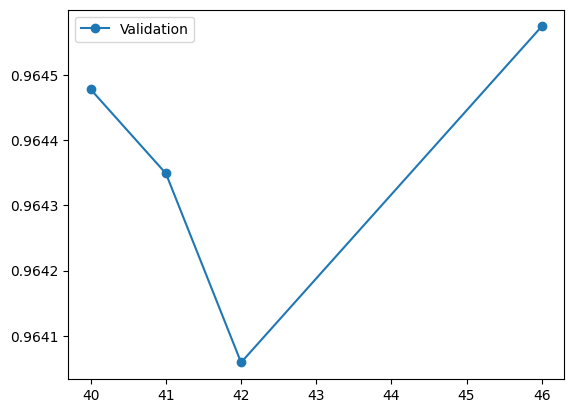

In [48]:
## plot of train and test scores vs tree depth
plt.plot( values_rf, val_scores_rf, '-o', label='Validation' )
plt.legend()
plt.show()

In [49]:
## Previsão sobre os dados de validacao
yhat_val_rf = model_rf.predict( X_val )
acc_val_rf = mt.accuracy_score( y_val, yhat_val_rf )
print( "Accuracy Over Validation: {}".format( acc_val_rf ) )

Accuracy Over Validation: 0.9635445155893047


In [50]:
## Modelo treinado e validado com o dataset de Treinamento
max_index_rf = val_scores_rf.index( max( val_scores_rf ) ) # Encontrar o índice do valor máximo de acurácia na lista de acurácias de validação
model_last_rf = RandomForestClassifier(n_estimators=values_rf[max_index_rf], max_depth=29)
model_last_rf.fit( np.concatenate( (X_train, X_val) ), np.concatenate((y_train, y_val)) )

/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",46
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",29
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [25]:
## Previsão sobre os dados de treinamento
yhat_train_rf = model_last_rf.predict( X_train )
acc_train_rf = mt.accuracy_score( y_train, yhat_train_rf )
precision_train_rf = mt.precision_score(y_train, yhat_train_rf)
recall_train_rf = mt.recall_score(y_train, yhat_train_rf)
f1_score_train_rf = mt.f1_score(y_train, yhat_train_rf)

print(f"F1 Score: {f1_score_train_rf}")
print(f"Precision: {precision_train_rf}")
print(f"Recall: {recall_train_rf}")
print( "Accuracy Over Training: {}".format( acc_train_rf ) )

/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


F1 Score: 0.9997931352736183
Precision: 1.0
Recall: 0.9995863561155658
Accuracy Over Training: 0.9998207267461905


In [26]:
## Previsão sobre os dados de validação
yhat_val_rf = model_last_rf.predict( X_val )
acc_val_rf = mt.accuracy_score( y_val, yhat_val_rf )
precision_val_rf = mt.precision_score(y_val, yhat_val_rf)
recall_val_rf = mt.recall_score(y_val, yhat_val_rf)
f1_score_val_rf = mt.f1_score(y_val, yhat_val_rf)

print(f"F1 Score: {f1_score_val_rf}")
print(f"Precision: {precision_val_rf}")
print(f"Recall: {recall_val_rf}")
print( "Accuracy Over Validation: {}".format( acc_val_rf ) )

/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


F1 Score: 0.9998143541380463
Precision: 1.0
Recall: 0.9996287771920707
Accuracy Over Validation: 0.9998391196627948


In [51]:
## Previsão sobre os dados de test
yhat_test_rf = model_last_rf.predict( X_test )
acc_test_rf = mt.accuracy_score( y_test, yhat_test_rf )
precision_rf = mt.precision_score(y_test, yhat_test_rf)
recall_rf = mt.recall_score(y_test, yhat_test_rf)
f1_score_rf = mt.f1_score(y_test, yhat_test_rf)

print(f"F1 Score: {f1_score_rf}")
print(f"Precision: {precision_rf}")
print(f"Recall: {recall_rf}")
print( "Accuracy Over Test: {}".format( acc_test_rf ) )

F1 Score: 0.9588784212171273
Precision: 0.9733502538071066
Recall: 0.944830620325561
Accuracy Over Test: 0.9644305410728768


/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


## Logistic Regressor

Nesta seção foi ajustado e avaliado um classificador `LogisticRegression`:

- treinou-se o modelo usando os dados de treinamento;
- avaliou-se a acurácia no conjunto de validação;
- gerou-se um gráfico com as pontuações de validação;
- re-treinou-se o modelo final com os dados combinados de treinamento e validação;
- avaliou-se o desempenho final no conjunto de teste usando acurácia, precisão, recall e F1-score.

In [ ]:
## Modelo treinado e validado com o dataset de Treinamento
values_lr = [1,50]
val_scores_lr= list()

for i in values_lr:
    model_lr = LogisticRegression(C=0.01, solver='lbfgs', max_iter=1000)
    model_lr.fit(X_train, y_train)

    yhat_val_lr = model_lr.predict(X_val)
    acc_val_lr = mt.accuracy_score(y_val, yhat_val_lr)
    val_scores_lr.append(acc_val_lr)

/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/s

In [159]:
## Previsão sobre os dados de treinamento
yhat_train_lr = model_lr.predict( X_train )
acc_train_lr = mt.accuracy_score( y_train, yhat_train_lr )
precision_train_lr = mt.precision_score(y_train, yhat_train_lr)
recall_train_lr = mt.recall_score(y_train, yhat_train_lr)
f1_score_train_lr = mt.f1_score(y_train, yhat_train_lr)

print(f"F1 Score: {f1_score_train_lr}")
print(f"Precision: {precision_train_lr}")
print(f"Recall: {recall_train_lr}")
print( "Accuracy Over Training: {}".format( acc_train_lr ) )

F1 Score: 0.85270263707445
Precision: 0.8679189322787939
Recall: 0.8380106911034746
Accuracy Over Training: 0.8745225125836034


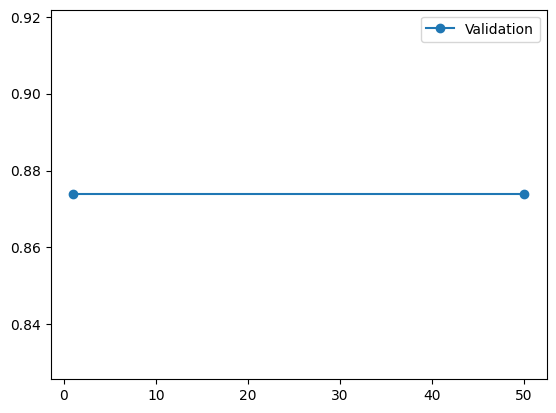

In [170]:
## plot of train and test scores vs tree depth
plt.plot( values_lr, val_scores_lr, '-o', label='Validation' )
plt.legend()
plt.show()

In [160]:
## Previsão sobre os dados de validação
yhat_val_lr = model_lr.predict( X_val )
acc_val_lr = mt.accuracy_score( y_val, yhat_val_lr )
precision_val_lr = mt.precision_score(y_val, yhat_val_lr)
recall_val_lr = mt.recall_score(y_val, yhat_val_lr)
f1_score_val_lr = mt.f1_score(y_val, yhat_val_lr)

print(f"F1 Score: {f1_score_val_lr}")
print(f"Precision: {precision_val_lr}")
print(f"Recall: {recall_val_lr}")
print( "Accuracy Over Validation: {}".format( acc_val_lr ) )

F1 Score: 0.8516319352520706
Precision: 0.8679463459759482
Recall: 0.835919518895241
Accuracy Over Validation: 0.8737732874288104


In [171]:
## Modelo treinado e validado com o dataset de Treinamento
max_index_lr = val_scores_lr.index( max( val_scores_lr ) ) # Encontrar o índice do valor máximo de acurácia na lista de acurácias de validação
model_last_lr = LogisticRegression(C=0.01, solver='lbfgs', max_iter=1000)
model_last_lr.fit( np.concatenate( (X_train, X_val) ), np.concatenate((y_train, y_val)) )

/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mu

In [172]:
## Previsão sobre os dados de test
yhat_test_lr = model_last_lr.predict( X_test )
acc_test_lr = mt.accuracy_score( y_test, yhat_test_lr )
precision_lr = mt.precision_score(y_test, yhat_test_lr)
recall_lr = mt.recall_score(y_test, yhat_test_lr)
f1_score_lr = mt.f1_score(y_test, yhat_test_lr)

print(f"F1 Score: {f1_score_lr}")
print(f"Precision: {precision_lr}")
print(f"Recall: {recall_lr}")
print( "Accuracy Over Test: {}".format( acc_test_lr ) )

F1 Score: 0.8493076784750944
Precision: 0.8682783344057359
Recall: 0.831148262208535
Accuracy Over Test: 0.8705441625149655


/home/alvaro/.pyenv/versions/3.14.2/envs/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


# Performace

## Resultados de treinamento

In [173]:
# criar tabela com os resultados da performace dos algorítimos de classificação com dados de teste
resultados_train = pd.DataFrame(columns=['Nome_do_algoritmo', 'Acurácia', 'Precision', 'Recall', 'F1_score'])

# adicionar os resultados do KNN à tabela
resultados_train.loc[0] = ['KNN',  acc_train_knn, precision_train_knn, recall_train_knn, f1_score_train_knn]
resultados_train.loc[1] = ['Decision Tree', acc_train_dt, precision_train_dt, recall_train_dt, f1_score_train_dt]
resultados_train.loc[2] = ['Random Forest', acc_train_rf, precision_train_rf, recall_train_rf, f1_score_train_rf]
resultados_train.loc[3] = ['Logistic Regression', acc_train_lr, precision_train_lr, recall_train_lr, f1_score_train_lr]

resultados_train = resultados_train.reset_index(drop=True)
resultados_train

,Nome_do_algoritmo,Acurácia,Precision,Recall,F1_score
0,KNN,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,1.000000,1.000000,1.000000,1.000000
2,Random Forest,0.999821,1.000000,0.999586,0.999793
3,Logistic Regression,0.874523,0.867919,0.838011,0.852703


## Resultados de validação

In [174]:
# criar tabela com os resultados da performace dos algorítimos de classificação com dados de validação
resultados_val = pd.DataFrame(columns=['Nome_do_algoritmo', 'Acurácia', 'Precision', 'Recall', 'F1_score'])

# adicionar os resultados do KNN à tabela
resultados_val.loc[0] = ['KNN',  acc_val_knn, precision_val_knn, recall_val_knn, f1_score_val_knn]
resultados_val.loc[1] = ['Decision Tree', acc_val_dt, precision_val_dt, recall_val_dt, f1_score_val_dt]
resultados_val.loc[2] = ['Random Forest', acc_val_rf, precision_val_rf, recall_val_rf, f1_score_val_rf]
resultados_val.loc[3] = ['Logistic Regression', acc_val_lr, precision_val_lr, recall_val_lr, f1_score_val_lr]

resultados_val = resultados_val.reset_index(drop=True)
resultados_val

,Nome_do_algoritmo,Acurácia,Precision,Recall,F1_score
0,KNN,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,0.945397,0.936453,0.937635,0.937043
2,Random Forest,0.963545,1.000000,0.999629,0.999814
3,Logistic Regression,0.873773,0.867946,0.835920,0.851632


## Resultados validados e testados

In [175]:
# criar tabela com os resultados da performace dos algorítimos de classificação com dados de teste
resultados_test = pd.DataFrame(columns=['Nome_do_algoritmo', 'Acurácia', 'Precision', 'Recall', 'F1_score'])

# adicionar os resultados do KNN à tabela
resultados_test.loc[0] = ['KNN',  acc_test_knn, precision_knn, recall_knn, f1_score_knn]
resultados_test.loc[1] = ['Decision Tree', acc_test_dt, precision_dt, recall_dt, f1_score_dt]
resultados_test.loc[2] = ['Random Forest', acc_test_rf, precision_rf, recall_rf, f1_score_rf]
resultados_test.loc[3] = ['Logistic Regression', acc_test_lr, precision_lr, recall_lr, f1_score_lr]

resultados_test = resultados_test.reset_index(drop=True)
resultados_test


,Nome_do_algoritmo,Acurácia,Precision,Recall,F1_score
0,KNN,0.698567,0.653766,0.665904,0.659779
1,Decision Tree,0.956513,0.956650,0.943687,0.950124
2,Random Forest,0.964431,0.973350,0.944831,0.958878
3,Logistic Regression,0.870544,0.868278,0.831148,0.849308
